In [18]:
import math
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from tqdm import tqdm
from collections import defaultdict
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objs as go
from matplotlib.animation import FuncAnimation
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedGroupKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import RobustScaler
from gtda.time_series import TakensEmbedding
# import helper_function as hf

In [3]:
#Lets import the speed data from BMN HisCl data to test with the lda build with normal worm speed
BMN_trig_speed_data=pd.read_csv(r"Z:\zimmer\jalaja\behaviour\Autoscope\BMN_Hiscl\stageposition\His_pos\BMN_His_trig_speed.csv",header=None)

In [10]:
BMN_trig_speed_data

,0,1,2,3,4,5,6,7,8,9,...,891,892,893,894,895,896,897,898,899,900
0,0.028178,0.042485,0.045607,0.037216,0.033615,0.018385,0.008485,0.018385,0.038897,0.029069,...,0.014765,0.013416,0.014318,0.014318,0.013000,0.019925,0.025710,0.062650,0.047927,0.0
1,0.031623,0.019313,0.000000,0.007000,0.027731,0.013416,0.012000,0.014318,0.014318,0.014765,...,0.040608,0.042485,0.028178,0.033242,0.023022,0.045000,0.047927,0.031575,0.014318,0.0
2,0.000000,0.012000,0.013000,0.020248,0.045880,0.063285,0.034540,0.044000,0.050000,0.054424,...,0.031401,0.014318,0.022472,0.037216,0.041593,0.020248,0.028636,0.031401,0.049679,0.0
3,0.075073,0.053740,0.028178,0.019925,0.037216,0.026173,0.051108,0.056798,0.041593,0.037216,...,0.008485,0.014318,0.013416,0.018385,0.022472,0.014318,0.025710,0.025710,0.032757,0.0
4,0.025000,0.032558,0.040162,0.031780,0.025710,0.023022,0.019925,0.025710,0.018385,0.013416,...,0.013416,0.019000,0.019000,0.026870,0.036069,0.043841,0.076844,0.081056,0.063008,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,NaN,0.272390,0.273840,0.257470,0.185950,0.146780,0.187880,0.169800,0.131610,0.130000,...,0.166580,0.195820,0.199160,0.237190,0.225840,0.264890,0.265660,NaN,0.263350,NaN
252,0.289940,0.271560,0.202710,0.287240,0.229800,0.176710,0.230530,0.169920,0.165950,0.133260,...,0.000000,0.000000,0.000000,0.009220,0.000000,0.006000,0.008485,0.007000,0.006000,NaN
253,0.000000,0.006000,0.006000,0.006000,0.007000,0.006000,0.009220,0.013416,0.014765,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
254,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
BMN_data=pd.DataFrame()
BMN_data['BMN_speed']=BMN_trig_speed_data.loc[:,551:600].mean(axis=1, skipna=True)
BMN_data['target']=BMN_trig_speed_data.iloc[:,-1]
BMN_data['group'] = np.repeat(np.arange(1, 17), 16)

In [12]:
BMN_data

,speed,target,group
0,0.028502,0.0,1
1,0.039575,0.0,1
2,0.037260,0.0,1
3,0.036815,0.0,1
4,0.022672,0.0,1
...,...,...,...
251,0.016262,NaN,16
252,0.030446,NaN,16
253,NaN,NaN,16
254,NaN,NaN,16


In [16]:
df_BMN=BMN_data[~BMN_data['target'].isna()]
df_BMN_nonan=df_BMN[~BMN_data['speed'].isna()]

In [25]:
df_BMN

,speed,target,group
0,0.028502,0.0,1
1,0.039575,0.0,1
2,0.037260,0.0,1
3,0.036815,0.0,1
4,0.022672,0.0,1
...,...,...,...
243,0.214028,0.0,16
246,0.121773,0.0,16
247,0.110991,1.0,16
248,0.081778,1.0,16


In [23]:
from numpy import mean
from numpy import std
def single_lda(data):
    dg = pd.DataFrame(index=data.columns.drop(['target','group']),columns=['mean_accuracy','std','mean_score','perm_accuaracy','p-value'])
    for neuron in data.columns.drop(['target','group']):
        ind_nan=data[neuron].isna()
        ind=ind_nan[ind_nan==False].index
        X=data[[neuron]].dropna()
        y =data.loc[ind,'target']
        groups=data.loc[ind,'group']
            
        model= LinearDiscriminantAnalysis()
        #model= LogisticRegression()
        model.fit(X,y)
        # cv = RepeatedStratifiedKFold(n_splits=10, random_state=None)
        cv= StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=0)
        #cv=GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        #cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        #cv=StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        # logo = LeaveOneGroupOut()
        # n_splits=logo.get_n_splits(X, y, groups)
        # cv=logo
        
        scores, perm_scores, pvalue = permutation_test_score(model, X, y, scoring="f1_weighted", cv=cv, groups=groups,n_permutations=2000)
        cv_scores = cross_val_score(model, X, y, scoring="f1_weighted", cv=cv,groups=groups,n_jobs=-1)
        print('Mean Accuracy: %.3f (%.3f)' % (mean(scores), std(cv_scores)))
        #print(scores)
        m=(mean(scores))

        s=(std(cv_scores))
        perm_mean_score=(mean(perm_scores))
        

        fig, ax = plt.subplots()

        hist_data, bins, _ = ax.hist(perm_scores, bins=20, density=True, color="tab:purple")
        # Calculate the x-coordinates for the shaded region
        # ax.errorbar(m, hist_data.max(), xerr=s, color="gray", lw=2, capsize=5)

        ax.axvline(m, ls="--", color="k")
        ax.axvline(perm_mean_score, ls="--", color="k")
        score_label = f"Score on original\ndata: {m:.2f}\n(p-value: {pvalue:.3f})"
        file_name = f"permutation_test_{neuron}.svg"
        ax.text(0.7, 10, score_label, fontsize=12)
        ax.set_xlabel("Accuracy score")
        _ = ax.set_ylabel("Probability density")
        plt.show()
        plt.savefig(file_name, format='svg')
        
        dg.loc[neuron, 'mean_accuracy'] = m
        dg.loc[neuron, 'mean_score'] = mean(cv_scores)
        dg.loc[neuron, 'std']=s
        dg.loc[neuron, 'perm_std']=std(perm_scores)
        dg.loc[neuron, 'perm_accuaracy'] = perm_mean_score
        dg.loc[neuron,'p-value']= pvalue
        
    return dg


Mean Accuracy: 0.570 (0.217)


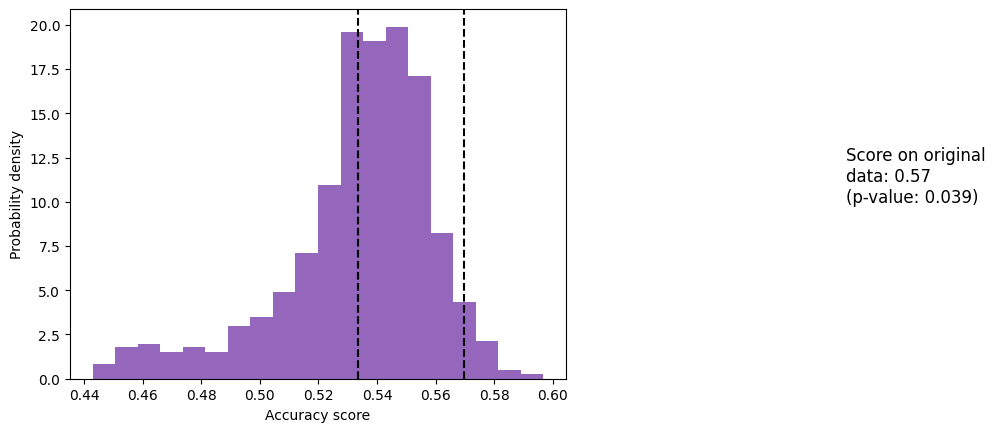

,mean_accuracy,std,mean_score,perm_accuaracy,p-value,perm_std
speed,0.569639,0.217371,0.569639,0.53341,0.038981,0.026058


<Figure size 640x480 with 0 Axes>

In [24]:
single_lda(df_BMN)